# 08 — 最終效能比較：Sweep 最佳配置 vs ORT 基線

從 `05_param_sweep.ipynb` 的全面參數掃描結果中，  
自動選出各精度（FP32 / FP16 / BF16 / INT8 / FP8）的最優 engine，  
與 ONNXRuntime 基線進行最終效能對比。

| 步驟 | 內容 |
|------|------|
| 1 | 路徑設定（讀取 sweep CSV） |
| 2 | ORT 基線 |
| 3 | 工具函式 |
| 4 | 從 Sweep CSV 自動選出各精度最佳配置 |
| 5 | Benchmark 所有最佳 Engine |
| 6 | 彙總比較表 |
| 7 | 視覺化 |

> **前置條件**：需先跑完 `05_param_sweep.ipynb`（`sweep/sweep_results.csv` 及對應 engine 已存在）。

## 1. 路徑設定

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src.env import *
setup_matplotlib()

SWEEP_DIR     = Path("sweep")
ENGINES_SWEEP = SWEEP_DIR / "engines"
SWEEP_CSV     = SWEEP_DIR / "sweep_results.csv"
COMPARE_DIR   = Path("compare")
COMPARE_DIR.mkdir(exist_ok=True)

assert TRTEXEC.exists(),    f"trtexec not found: {TRTEXEC}"
assert ONNX_MODEL.exists(), f"ONNX model not found: {ONNX_MODEL}"
assert SWEEP_CSV.exists(),  f"Sweep CSV not found — 請先跑 05_param_sweep.ipynb: {SWEEP_CSV}"

print("Paths OK")
print(f"  ONNX model        : {ONNX_MODEL}")
print(f"  Sweep CSV         : {SWEEP_CSV}")
print(f"  Warmup / Duration : {WARMUP_MS}ms / {DURATION_S}s")

Font loaded: Cubic 11  (D:\tensorrt\book\src\fonts\Cubic_11.ttf)
Paths OK
  ONNX model        : C:\GPM_AI\H.onnx
  Sweep CSV         : sweep\sweep_results.csv
  Warmup / Duration : 500ms / 10s


## 2. ORT 基線

原始 `.onnx` 透過 ONNXRuntime 推論，代表「完全不使用 TensorRT」的基線成本。

> 本機 GPU 為 RTX 5070 Laptop（Blackwell，SM 12.0）。`onnxruntime-gpu` 目前的 `CUDAExecutionProvider`  
> 在 SM 12.0 初始化失敗，自動 fallback 至 `CPUExecutionProvider`，實際測量的是 CPU 延遲。  
> trtexec 能跑是因為 TensorRT 10.8 針對 CUDA 12.8 + SM 12.0 獨立編譯。

In [2]:
import onnx
import onnxruntime as ort
import numpy as np
import time

# 讀取模型輸入 shape
_m    = onnx.load(str(ONNX_MODEL))
_dims = _m.graph.input[0].type.tensor_type.shape.dim
MODEL_C = _dims[1].dim_value or 3
MODEL_H = _dims[2].dim_value or 448
MODEL_W = _dims[3].dim_value or 448
print(f"Model input shape : [1, {MODEL_C}, {MODEL_H}, {MODEL_W}]")
print(f"ORT version       : {ort.__version__}")
print(f"Available EPs     : {ort.get_available_providers()}")
print()

session = ort.InferenceSession(
    str(ONNX_MODEL),
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)
active_ep = session.get_providers()[0]
ep_short  = active_ep.replace("ExecutionProvider", "")
inp_name  = session.get_inputs()[0].name
out_name  = session.get_outputs()[0].name

if "CPU" in active_ep:
    print("⚠  CUDAExecutionProvider 初始化失敗（SM 12.0 / Blackwell 未受此版本 onnxruntime-gpu 支援）")
    print("   自動回退 CPUExecutionProvider — 測量的是 CPU 延遲")
else:
    print(f"✓  GPU EP 啟用：{ep_short}")
print()

dummy = np.random.rand(1, MODEL_C, MODEL_H, MODEL_W).astype(np.float32)

# Warmup
print(f"  Warmup {WARMUP_MS} ms ...")
_t_wu = time.perf_counter() + WARMUP_MS / 1000.0
while time.perf_counter() < _t_wu:
    session.run([out_name], {inp_name: dummy})

# Timed runs
print(f"  Benchmark {DURATION_S} s ...")
lat_list = []
_t_end = time.perf_counter() + DURATION_S
while time.perf_counter() < _t_end:
    t0 = time.perf_counter()
    session.run([out_name], {inp_name: dummy})
    lat_list.append((time.perf_counter() - t0) * 1000)
lat_ort = np.array(lat_list)

m_ort = {
    "label":          f"ORT {ep_short}（初始）",
    "mean_ms":        float(lat_ort.mean()),
    "median_ms":      float(np.median(lat_ort)),
    "p95_ms":         float(np.percentile(lat_ort, 95)),
    "p99_ms":         float(np.percentile(lat_ort, 99)),
    "throughput_qps": float(1000 / lat_ort.mean()),
}
print(f"[ORT {ep_short}]  mean={m_ort['mean_ms']:.3f}ms  "
      f"p95={m_ort['p95_ms']:.3f}ms  QPS={m_ort['throughput_qps']:.1f}  "
      f"({len(lat_list)} iterations)")

Model input shape : [1, 3, 448, 448]
ORT version       : 1.26.0
Available EPs     : ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']

⚠  CUDAExecutionProvider 初始化失敗（SM 12.0 / Blackwell 未受此版本 onnxruntime-gpu 支援）
   自動回退 CPUExecutionProvider — 測量的是 CPU 延遲

  Warmup 500 ms ...
  Benchmark 10 s ...
[ORT CPU]  mean=115.689ms  p95=220.699ms  QPS=8.6  (87 iterations)


## 3. 工具函式 — trtexec build / benchmark

In [3]:
import subprocess, re, time


def parse_trtexec(stdout: str) -> dict:
    patterns = {
        "mean_ms":        r"mean\s*=\s*([\d.]+)\s*ms",
        "median_ms":      r"median\s*=\s*([\d.]+)\s*ms",
        "p95_ms":         r"percentile\(95%\)\s*=\s*([\d.]+)\s*ms",
        "p99_ms":         r"percentile\(99%\)\s*=\s*([\d.]+)\s*ms",
        "throughput_qps": r"Throughput:\s*([\d.]+)\s*qps",
        "gpu_compute_ms": r"GPU Compute Time.*?mean\s*=\s*([\d.]+)\s*ms",
    }
    return {
        k: float(m.group(1))
        for k, pat in patterns.items()
        if (m := re.search(pat, stdout, re.IGNORECASE))
    }


def build_engine(onnx_path: Path, engine_path: Path, extra_flags=()) -> bool:
    """Build a TRT engine with trtexec.  Returns True on success."""
    cmd = [
        str(TRTEXEC),
        f"--onnx={onnx_path}",
        f"--saveEngine={engine_path}",
        "--skipInference",
        *extra_flags,
    ]
    print(f"Building: {engine_path.name}")
    print(f"  Flags: {extra_flags if extra_flags else '(none — TRT defaults)'}")
    t0   = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.time() - t0
    if proc.returncode != 0:
        print(f"  FAILED ({elapsed:.1f}s):\n{proc.stderr[-400:]}")
        return False
    size_kb = engine_path.stat().st_size // 1024
    print(f"  Done  build_time={elapsed:.1f}s  size={size_kb}KB")
    return True


def benchmark_engine(engine_path: Path, label: str) -> dict:
    """Benchmark an existing engine.  Returns metrics dict."""
    cmd = [
        str(TRTEXEC),
        f"--loadEngine={engine_path}",
        f"--warmUp={WARMUP_MS}",
        f"--duration={DURATION_S}",
    ]
    t0   = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.time() - t0
    if proc.returncode != 0:
        print(f"  [{label}] FAILED: {proc.stderr[-200:]}")
        return {"label": label, "success": False}
    m = parse_trtexec(proc.stdout)
    m["label"]   = label
    m["success"] = True
    print(f"[{label}]\n"
          f"  mean={m.get('mean_ms', float('nan')):.3f}ms  "
          f"p95={m.get('p95_ms', float('nan')):.3f}ms  "
          f"QPS={m.get('throughput_qps', float('nan')):.1f}  "
          f"({elapsed:.1f}s)")
    return m


print("Helper functions loaded.")

Helper functions loaded.


## 4. 從 Sweep 結果選出各精度最佳配置

讀取 `05_param_sweep.ipynb` 產生的 CSV，針對每種精度在 static-batch 模式下  
選出 `mean_ms` 最小的配置，並確認對應 engine 檔案存在。  
同時支援新命名格式（`_static` 後綴）與舊格式（無後綴）。

In [4]:
import pandas as pd
import numpy as np

df_sweep = pd.read_csv(SWEEP_CSV)
if "batch_mode" not in df_sweep.columns:
    df_sweep["batch_mode"] = "static"
df_ok = df_sweep[df_sweep["success"] == True].copy()
df_ok["builder_opt_level"] = df_ok["builder_opt_level"].astype(int)
df_ok["workspace_mb"]      = df_ok["workspace_mb"].astype(int)

print(f"Sweep results loaded: {len(df_ok)} successful configs\n")

PREC_ORDER = ["fp32", "fp16", "bf16", "int8", "fp8"]
best_per_prec = {}

for prec in PREC_ORDER:
    sub = df_ok[(df_ok["precision"] == prec) & (df_ok["batch_mode"] == "static")]
    if len(sub) == 0:
        print(f"  [{prec:>4}] no data — skipped")
        continue
    best = sub.loc[sub["mean_ms"].idxmin()]
    opt, ws = int(best.builder_opt_level), int(best.workspace_mb)

    # 支援新（_static）與舊（無後綴）兩種命名
    new_path = ENGINES_SWEEP / f"H_{prec}_opt{opt}_ws{ws}mb_static.engine"
    old_path = ENGINES_SWEEP / f"H_{prec}_opt{opt}_ws{ws}mb.engine"
    engine_path = new_path if new_path.exists() else (old_path if old_path.exists() else new_path)

    best_per_prec[prec] = {
        "label":       f"TRT {prec.upper()} (opt={opt}, ws={ws}MB)",
        "engine_path": engine_path,
    }
    status = "✓" if engine_path.exists() else "✗ MISSING"
    print(f"  [{prec:>4}] opt={opt} ws={ws}MB  sweep_mean={best['mean_ms']:.3f}ms  "
          f"engine {status}: {engine_path.name}")

print(f"\n{len(best_per_prec)} precisions ready for benchmark.")

Sweep results loaded: 40 successful configs

  [fp32] opt=5 ws=1024MB  sweep_mean=3.294ms  engine ✓: H_fp32_opt5_ws1024mb_static.engine
  [fp16] opt=4 ws=1024MB  sweep_mean=1.388ms  engine ✓: H_fp16_opt4_ws1024mb_static.engine
  [bf16] opt=5 ws=256MB  sweep_mean=3.142ms  engine ✓: H_bf16_opt5_ws256mb_static.engine
  [int8] opt=4 ws=1024MB  sweep_mean=1.003ms  engine ✓: H_int8_opt4_ws1024mb_static.engine
  [ fp8] opt=5 ws=1024MB  sweep_mean=3.281ms  engine ✓: H_fp8_opt5_ws1024mb_static.engine

5 precisions ready for benchmark.


## 5. Benchmark 各精度最佳 Engine

依序執行 `trtexec --loadEngine` 量測各精度最佳 engine，結果合入 `all_results`。

In [5]:
all_results = [m_ort]  # ORT 基線已在 Cell 2 執行

for prec in PREC_ORDER:
    info = best_per_prec.get(prec)
    if info is None:
        print(f"[{prec.upper()}] skipped — no sweep data")
        continue
    ep = info["engine_path"]
    if not ep.exists():
        print(f"[{info['label']}] engine missing: {ep}")
        all_results.append({"label": info["label"], "success": False})
        continue
    m = benchmark_engine(ep, info["label"])
    all_results.append(m)

n_ok = sum(1 for r in all_results if r.get("success"))
print(f"\nBenchmark complete — {n_ok} / {len(all_results)} OK")

[TRT FP32 (opt=5, ws=1024MB)]
  mean=3.091ms  p95=3.612ms  QPS=307.1  (13.7s)
[TRT FP16 (opt=4, ws=1024MB)]
  mean=1.417ms  p95=2.035ms  QPS=644.5  (11.1s)
[TRT BF16 (opt=5, ws=256MB)]
  mean=3.337ms  p95=3.664ms  QPS=284.4  (11.2s)
[TRT INT8 (opt=4, ws=1024MB)]
  mean=0.969ms  p95=1.256ms  QPS=901.7  (10.9s)
[TRT FP8 (opt=5, ws=1024MB)]
  mean=3.549ms  p95=3.810ms  QPS=268.4  (11.0s)

Benchmark complete — 5 / 6 OK


## 6. 彙總比較表

In [6]:
import pandas as pd
import numpy as np

good = [r for r in all_results if r.get("success")]

df = pd.DataFrame([
    {
        "配置":         r["label"],
        "Mean (ms)":   round(r.get("mean_ms",        float("nan")), 3),
        "Median (ms)": round(r.get("median_ms",      float("nan")), 3),
        "P95 (ms)":    round(r.get("p95_ms",         float("nan")), 3),
        "P99 (ms)":    round(r.get("p99_ms",         float("nan")), 3),
        "QPS":         round(r.get("throughput_qps", float("nan")), 1),
    }
    for r in good
])

ort_mean = df.loc[0, "Mean (ms)"]
df["vs ORT (加速比)"] = (ort_mean / df["Mean (ms)"]).round(2)

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

print("=" * 130)
print(df.to_string(index=False))
print("=" * 130)

if len(df) > 1:
    best_row = df.iloc[1:].loc[df.iloc[1:]["Mean (ms)"].idxmin()]
    print(f"\n>>> Best TRT config : {best_row['配置']}")
    print(f"    mean={best_row['Mean (ms)']:.3f}ms  QPS={best_row['QPS']:.1f}  "
          f"vs ORT={best_row['vs ORT (加速比)']:.1f}×")

                         配置  Mean (ms)  Median (ms)  P95 (ms)  P99 (ms)     QPS  vs ORT (加速比)
TRT FP32 (opt=5, ws=1024MB)      3.091        3.004     3.612     4.953 307.100         1.000
TRT FP16 (opt=4, ws=1024MB)      1.417        1.307     2.035     3.368 644.500         2.180
 TRT BF16 (opt=5, ws=256MB)      3.337        3.380     3.664     4.385 284.400         0.930
TRT INT8 (opt=4, ws=1024MB)      0.969        0.914     1.256     1.428 901.700         3.190
 TRT FP8 (opt=5, ws=1024MB)      3.549        3.680     3.810     4.099 268.400         0.870

>>> Best TRT config : TRT INT8 (opt=4, ws=1024MB)
    mean=0.969ms  QPS=901.7  vs ORT=3.2×


## 7. 視覺化

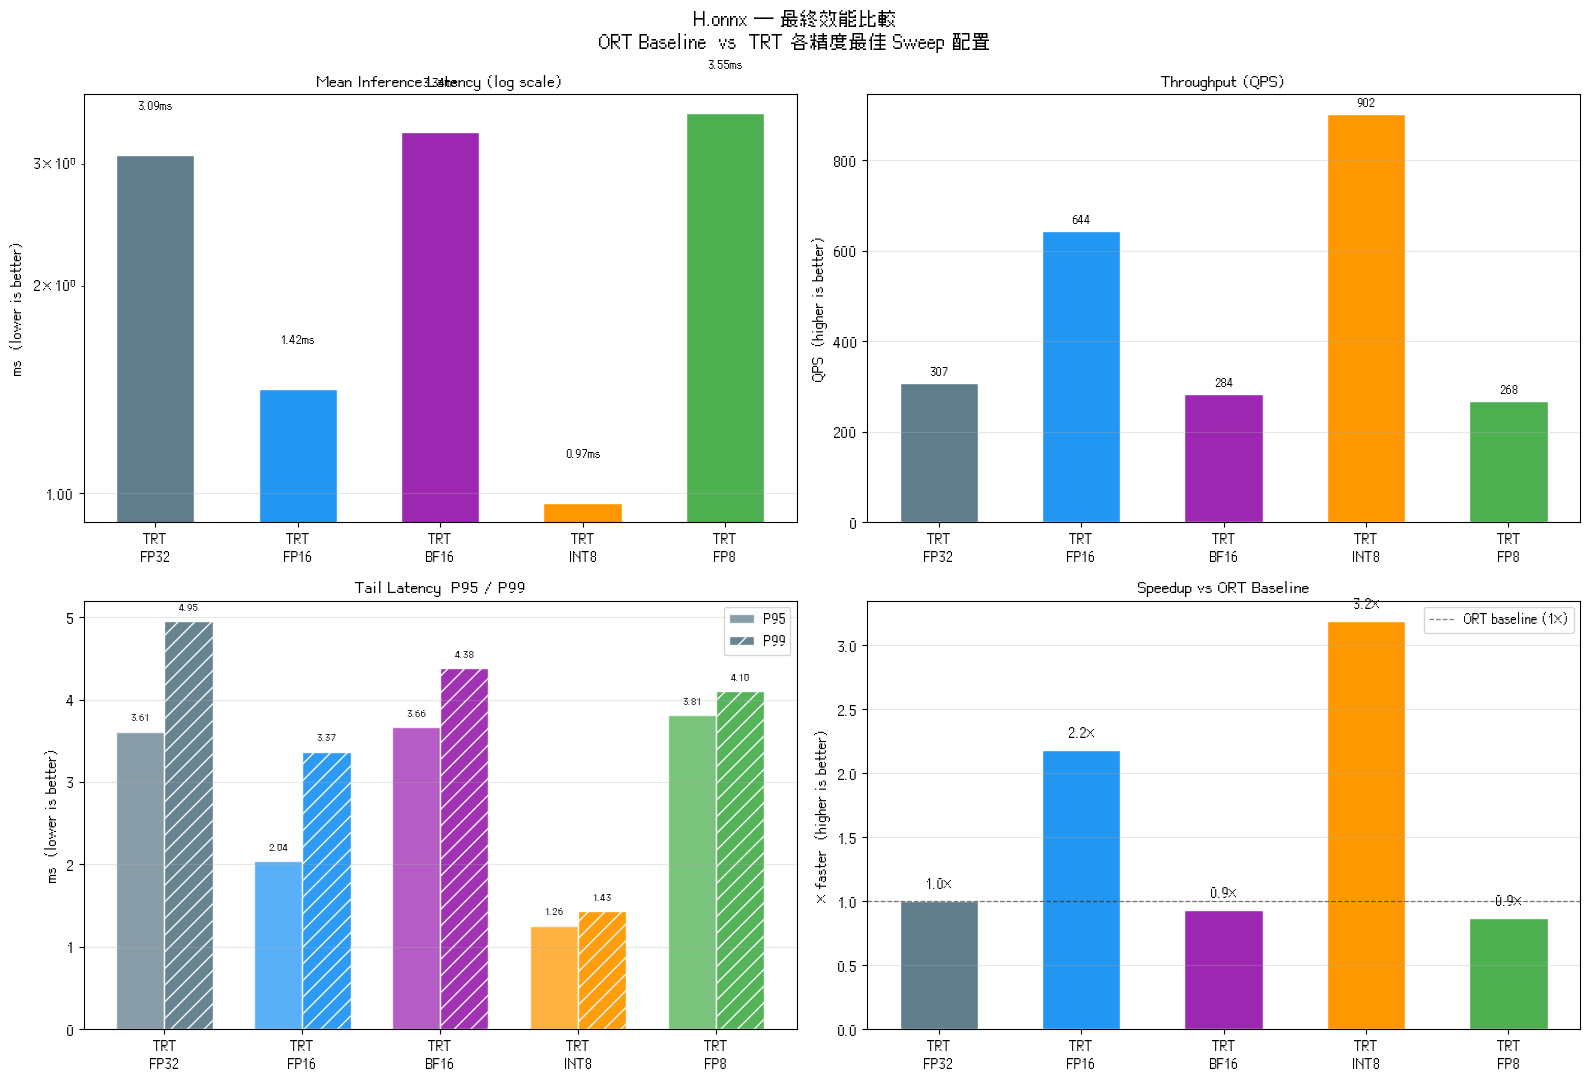

Saved → compare\final_comparison_results.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

labels    = df["配置"].tolist()
mean_vals = df["Mean (ms)"].tolist()
p95_vals  = df["P95 (ms)"].tolist()
p99_vals  = df["P99 (ms)"].tolist()
qps_vals  = df["QPS"].tolist()
spd_vals  = df["vs ORT (加速比)"].tolist()

PREC_COLORS = {
    "fp32": "#607D8B", "fp16": "#2196F3", "bf16": "#9C27B0",
    "int8": "#FF9800", "fp8":  "#4CAF50",
}

def _color(label: str) -> str:
    lb = label.lower()
    for prec, c in PREC_COLORS.items():
        if prec in lb:
            return c
    return "#9E9E9E"

def _short(label: str) -> str:
    for prec in ["fp32", "fp16", "bf16", "int8", "fp8"]:
        if prec in label.lower():
            return f"TRT\n{prec.upper()}"
    return label.replace("ExecutionProvider", "").replace(" ", "\n")

COLORS      = [_color(l) for l in labels]
plot_labels = [_short(l) for l in labels]
x = np.arange(len(labels))
w = 0.35
has_tail = any(not np.isnan(v) for v in p95_vals)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── 1. Mean latency (log scale) ───────────────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(x, mean_vals, color=COLORS, width=0.55, edgecolor="white")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
for bar, val in zip(bars, mean_vals):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.15,
                f"{val:.2f}ms", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_title("Mean Inference Latency (log scale)", fontsize=11)
ax.set_ylabel("ms  (lower is better)")
ax.set_xticks(x); ax.set_xticklabels(plot_labels, fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── 2. Throughput (QPS) ───────────────────────────────────────────────────
ax = axes[0, 1]
bars = ax.bar(x, qps_vals, color=COLORS, width=0.55, edgecolor="white")
ymax = max(qps_vals)
for bar, val in zip(bars, qps_vals):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + ymax * 0.01,
                f"{val:.0f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_title("Throughput (QPS)", fontsize=11)
ax.set_ylabel("QPS  (higher is better)")
ax.set_xticks(x); ax.set_xticklabels(plot_labels, fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── 3. Tail latency P95 / P99 ─────────────────────────────────────────────
ax = axes[1, 0]
if has_tail:
    bp95 = ax.bar(x - w/2, p95_vals, w, label="P95",
                  color=COLORS, alpha=0.75, edgecolor="white")
    bp99 = ax.bar(x + w/2, p99_vals, w, label="P99",
                  color=COLORS, alpha=0.95, edgecolor="white", hatch="//")
    valid = [v for v in p95_vals + p99_vals if not np.isnan(v)]
    ymax_t = max(valid) if valid else 1.0
    for bar in list(bp95) + list(bp99):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + ymax_t * 0.02,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=7)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "P95/P99 not available", transform=ax.transAxes,
            ha="center", va="center", fontsize=12, color="gray")
ax.set_title("Tail Latency  P95 / P99", fontsize=11)
ax.set_ylabel("ms  (lower is better)")
ax.set_xticks(x); ax.set_xticklabels(plot_labels, fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── 4. Speedup vs ORT baseline ────────────────────────────────────────────
ax = axes[1, 1]
bars = ax.bar(x, spd_vals, color=COLORS, width=0.55, edgecolor="white")
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.9, alpha=0.5, label="ORT baseline (1×)")
ymax_s = max(spd_vals)
for bar, val in zip(bars, spd_vals):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + ymax_s * 0.02,
                f"{val:.1f}×", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Speedup vs ORT Baseline", fontsize=11)
ax.set_ylabel("× faster  (higher is better)")
ax.set_xticks(x); ax.set_xticklabels(plot_labels, fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "H.onnx — 最終效能比較\nORT Baseline  vs  TRT 各精度最佳 Sweep 配置",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()

out_png = COMPARE_DIR / "final_comparison_results.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_png}")